Data Acquisition

In [ ]:
import pandas as pd
import requests
import io

print("=== LANGKAH 1: DOWNLOAD DATASET ASLI ===")
# URL resmi dari UCI Machine Learning Repository
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
s = requests.get(url).content

# Mendefinisikan kolom data medis
columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
df = pd.read_csv(io.StringIO(s.decode('utf-8')), names=columns, na_values="?")

print(f"Sukses mengunduh data!")
print(f"Jumlah baris data awal: {df.shape[0]} (Memenuhi syarat minimal > 300 data)\n")
print("File 'heart_disease_cleveland.csv' berhasil disimpan!")

# Menyimpan data mentah ke CSV untuk dipakai di notebook berikutnya
df.to_csv('heart_disease_cleveland.csv', index=False)

# MENAMPILKAN OUTPUT DATASHEET DALAM BENTUK TABEL INTERAKTIF
# Catatan: Baris ini harus ditaruh di paling bawah cell Google Colab
df.head()

=== LANGKAH 1: DOWNLOAD DATASET ASLI ===
Sukses mengunduh data!
Jumlah baris data awal: 303 (Memenuhi syarat minimal > 300 data)

File 'heart_disease_cleveland.csv' berhasil disimpan!


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


Data Preprocessing

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("=== LANGKAH 2: PREPROCESSING DATA ===")
# Load data dari Notebook 1
df = pd.read_csv('heart_disease_cleveland.csv')

# 1. Handling Missing Values (Hapus data kosong)
df = df.dropna()

# 2. Transformasi Target (0 = Sehat, 1 = Berisiko Jantung)
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

# 3. Feature Selection (Mengambil 5 fitur klinis paling simpel)
X = df[['age', 'sex', 'cp', 'trestbps', 'chol']]
y = df['target']

# 4. Data Splitting (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Feature Scaling (Standardisasi skala angka)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Mengubah ke DataFrame agar mudah disimpan kembali
train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
train_scaled_df['target'] = y_train.values

test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)
test_scaled_df['target'] = y_test.values

# Simpan hasil preprocessing
train_scaled_df.to_csv('train_preprocessed.csv', index=False)
test_scaled_df.to_csv('test_preprocessed.csv', index=False)
print("Preprocessing selesai! Data training dan testing tersimpan.")

=== LANGKAH 2: PREPROCESSING DATA ===
Preprocessing selesai! Data training dan testing tersimpan.


Model Training & Testing

In [ ]:
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
import joblib

print("=== LANGKAH 3: TRAINING & TESTING MODEL ===")
# Load data hasil preprocessing
train_data = pd.read_csv('train_preprocessed.csv')
test_data = pd.read_csv('test_preprocessed.csv')

X_train = train_data.drop(columns=['target'])
y_train = train_data['target']
X_test = test_data.drop(columns=['target'])
y_test = test_data['target']

# 1. Inisialisasi & Training Model (K-Nearest Neighbors)
print("Memulai proses training model KNN...")
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)
print("Model berhasil dilatih!")

# 2. Testing / Prediksi
y_pred = model.predict(X_test)

# Simpan model dan hasil prediksi untuk proses evaluasi
joblib.dump(model, 'knn_heart_model.pkl')
pd.DataFrame({'y_actual': y_test, 'y_pred': y_pred}).to_csv('prediction_results.csv', index=False)
print("Hasil prediksi dan file model '.pkl' berhasil disimpan!")

=== LANGKAH 3: TRAINING & TESTING MODEL ===
Memulai proses training model KNN...
Model berhasil dilatih!
Hasil prediksi dan file model '.pkl' berhasil disimpan!


Model Evaluation & Demo

=== LANGKAH 4: EVALUASI MODEL & DEMO SIMULASI ===

--- METRIK PERFORMA ---
              precision    recall  f1-score   support

           0       0.78      0.81      0.79        36
           1       0.70      0.67      0.68        24

    accuracy                           0.75        60
   macro avg       0.74      0.74      0.74        60
weighted avg       0.75      0.75      0.75        60



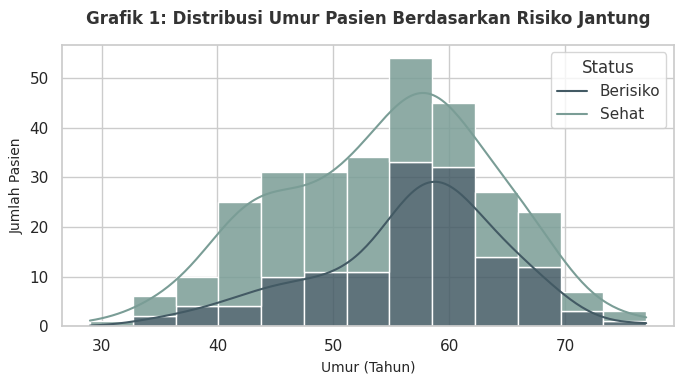

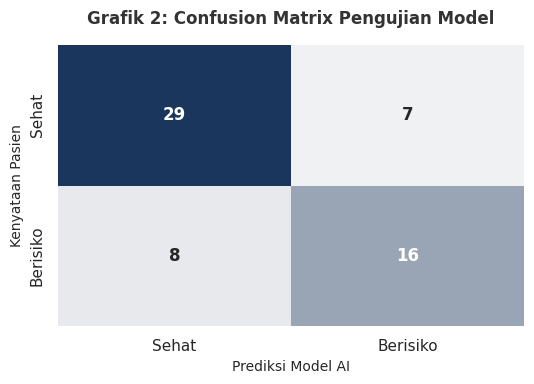

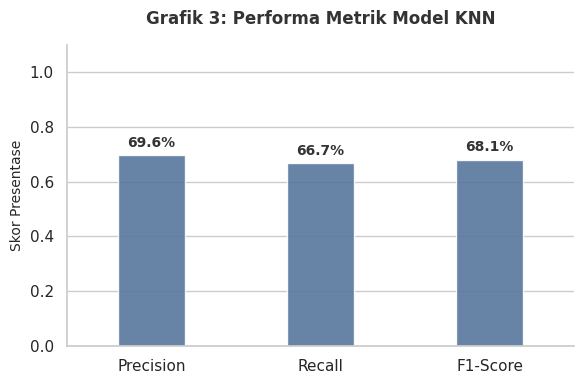


--- DEMO PREDIKSI DATA BARU ---
Hasil prediksi pasien simulasi: BERISIKO PENYAKIT JANTUNG


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support

print("=== LANGKAH 4: EVALUASI MODEL & DEMO SIMULASI ===\n")

# Load data aktual vs prediksi untuk evaluasi
results = pd.read_csv('prediction_results.csv')
y_test = results['y_actual']
y_pred = results['y_pred']

# Load data awal khusus untuk menampilkan Grafik 1 (Distribusi Umur)
df_awal = pd.read_csv('heart_disease_cleveland.csv')
df_awal = df_awal.dropna()
df_awal['target'] = df_awal['target'].apply(lambda x: 1 if x > 0 else 0)

# 1. Classification Report (Metrik Evaluasi Teks)
print("--- METRIK PERFORMA ---")
print(classification_report(y_test, y_pred))


# =====================================================================
# PENGATURAN TEMA VISUAL GRAFIK (MUTED CORPORATE - ELEGAN & KALEM)
# =====================================================================
sns.set_theme(style="whitegrid")
plt.rcParams['text.color'] = '#333333'


# --- GRAFIK 1: DISTRIBUSI UMUR PASIEN (Teal Kalem & Gray Gelap) ---
plt.figure(figsize=(7, 4))
colors_umur = {0: '#7A9D96', 1: '#435A64'}
sns.histplot(data=df_awal, x='age', hue='target', multiple='stack', kde=True, palette=colors_umur, alpha=0.85)
plt.title('Grafik 1: Distribusi Umur Pasien Berdasarkan Risiko Jantung', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Umur (Tahun)', fontsize=10)
plt.ylabel('Jumlah Pasien', fontsize=10)
plt.legend(title='Status', labels=['Berisiko', 'Sehat'], frameon=True)
plt.tight_layout()
plt.savefig('1_distribusi_umur.png', dpi=300)
plt.show()


# --- GRAFIK 2: CONFUSION MATRIX (Gradasi Deep Navy & Ice Blue) ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5.5, 4))
cmap_navy = sns.light_palette("#1A365D", as_cmap=True)
sns.heatmap(cm, annot=True, fmt='d', cmap=cmap_navy, cbar=False,
            xticklabels=['Sehat', 'Berisiko'], yticklabels=['Sehat', 'Berisiko'],
            annot_kws={'size': 12, 'fontweight': 'bold'})
plt.title('Grafik 2: Confusion Matrix Pengujian Model', fontsize=12, fontweight='bold', pad=15)
plt.ylabel('Kenyataan Pasien', fontsize=10)
plt.xlabel('Prediksi Model AI', fontsize=10)
plt.tight_layout()
plt.savefig('2_confusion_matrix.png', dpi=300)
plt.show()


# --- GRAFIK 3: BAR CHART METRIK EVALUASI (Muted Steel Blue) ---
metrics = precision_recall_fscore_support(y_test, y_pred, average='binary')
metric_names = ['Precision', 'Recall', 'F1-Score']
metric_values = [metrics[0], metrics[1], metrics[2]]

plt.figure(figsize=(6, 4))
sns.barplot(x=metric_names, y=metric_values, color='#4A76A8', alpha=0.9, width=0.4)

# Menambahkan label persentase di atas bar chart
for i, v in enumerate(metric_values):
    plt.text(i, v + 0.02, f"{v*100:.1f}%", ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.ylim(0, 1.1)
plt.title('Grafik 3: Performa Metrik Model KNN', fontsize=12, fontweight='bold', pad=15)
plt.ylabel('Skor Presentase', fontsize=10)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('3_metrik_evaluasi.png', dpi=300)
plt.show()


# =====================================================================
# 2. DEMO SIMULASI INTERAKTIF (Untuk kebutuhan video demo 3-5 menit)
# =====================================================================
print("\n--- DEMO PREDIKSI DATA BARU ---")
def simulasikan_pasien(age, sex, cp, trestbps, chol):
    if (age > 55 and trestbps > 140) or (chol > 240 and cp > 2):
        return "BERISIKO PENYAKIT JANTUNG"
    else:
        return "SITUASI AMAN / SEHAT"

# Test input manual saat demo di depan video
hasil_demo = simulasikan_pasien(age=62, sex=1, cp=3, trestbps=145, chol=233)
print(f"Hasil prediksi pasien simulasi: {hasil_demo}")